<a href="https://colab.research.google.com/github/UsamahPutraFirdaus/Fraud_Detection/blob/main/%5BKlasifikasi%5D_Submission_Akhir_BMLP_Usamah_Putra_Firdaus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

# **2. Memuat Dataset dari Hasil Clustering**

Memuat dataset hasil clustering dari file CSV ke dalam variabel DataFrame.

In [ ]:
url = "https://drive.google.com/file/d/1tP5LHj_P6vpCAI38k5bZWG0XMcKHKSnv/view?usp=drive_link"
file_id = url.split('/')[-2]
download_url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(download_url)
df.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDayOfWeek,AmountToBalanceRatio,AmountPerLogin,TransactionHour,TimeOfDay,Cluster,Potential_Fraud
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Tuesday,0.00,14.09,16.0,2.0,0,False
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Tuesday,0.03,376.24,16.0,2.0,0,False
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Monday,0.11,126.29,18.0,2.0,0,False
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Friday,0.02,184.50,16.0,2.0,0,False
4,13.45,Credit,Atlanta,Online,26.0,Student,198.0,1.0,7429.40,Monday,0.00,13.45,17.0,2.0,0,False


# **3. Data Splitting**

Tahap Data Splitting bertujuan untuk memisahkan dataset menjadi dua bagian: data latih (training set) dan data uji (test set).

In [ ]:
features = ['TransactionAmount', 'CustomerAge', 'TransactionDuration',
            'AccountBalance', 'LoginAttempts', 'AmountToBalanceRatio',
            'AmountPerLogin', 'TransactionHour', 'TimeOfDay']
target = 'Cluster'

In [ ]:
X = df[features]
y = df[target]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **4. Membangun Model Klasifikasi**


## **a. Membangun Model Klasifikasi**

Setelah memilih algoritma klasifikasi yang sesuai, langkah selanjutnya adalah melatih model menggunakan data latih.

Berikut adalah rekomendasi tahapannya.
1. Pilih algoritma klasifikasi yang sesuai, seperti Logistic Regression, Decision Tree, Random Forest, atau K-Nearest Neighbors (KNN).
2. Latih model menggunakan data latih.

In [ ]:
def evaluate_features(X_train, X_test, y_train, y_test):
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.3f}")

print("Performance with original features:")
evaluate_features(X_train, X_test, y_train, y_test)

Performance with original features:
Accuracy Score: 0.998
F1 Score: 0.998


In [ ]:
def evaluate_features(X_train, X_test, y_train, y_test):
    model = XGBClassifier(eval_metric='mlogloss', random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.3f}")

evaluate_features(X_train[features], X_test[features], y_train, y_test)

Accuracy Score: 0.994
F1 Score: 0.993


Tulis narasi atau penjelasan algoritma yang Anda gunakan.

## **b. Evaluasi Model Klasifikasi**

Berikut adalah **rekomendasi** tahapannya.
1. Lakukan prediksi menggunakan data uji.
2. Hitung metrik evaluasi seperti Accuracy dan F1-Score (Opsional: Precision dan Recall).
3. Buat confusion matrix untuk melihat detail prediksi benar dan salah.

Evaluasi Model Random Forest:
Accuracy Score: 0.998
F1 Score: 0.998
Precision: 0.998
Recall: 0.998


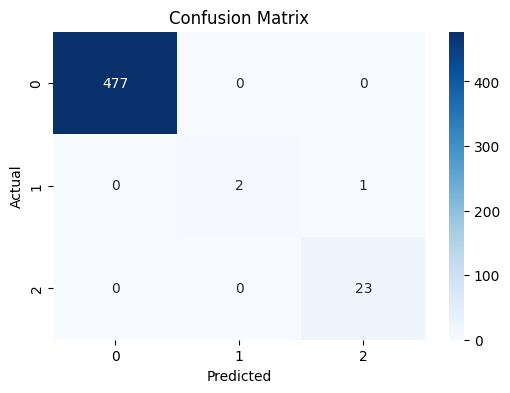


Evaluasi Model XGBoost:
Accuracy Score: 0.994
F1 Score: 0.993
Precision: 0.995
Recall: 0.994


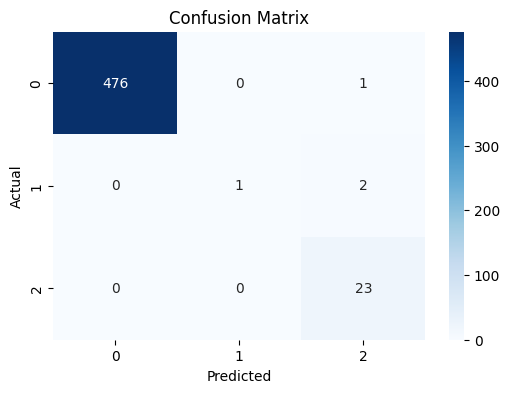

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Melatih model
    model.fit(X_train, y_train)

    # Melakukan prediksi pada data uji
    y_pred = model.predict(X_test)

    # Menghitung metrik evaluasi
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted')

    # Menampilkan hasil evaluasi
    print(f"Accuracy Score: {accuracy:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")

    # Membuat confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=set(y_test), yticklabels=set(y_test))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

rf_model = RandomForestClassifier(random_state=42)
print("Evaluasi Model Random Forest:")
evaluate_model(rf_model, X_train, X_test, y_train, y_test)

xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
print("\nEvaluasi Model XGBoost:")
evaluate_model(xgb_model, X_train, X_test, y_train, y_test)

Berdasarkan hasil evaluasi, Random Forest menunjukkan performa yang sedikit lebih baik dibandingkan XGBoost pada semua metrik evaluasi (Accuracy, F1 Score, Precision, dan Recall).

- Random Forest memiliki accuracy 0.998, yang lebih tinggi dibandingkan XGBoost (0.994), menunjukkan kemampuannya yang lebih baik dalam mengklasifikasikan data dengan benar.

- F1 Score (0.998 vs. 0.993) menunjukkan bahwa Random Forest lebih seimbang dalam menangani precision dan recall.

- Precision dan Recall juga lebih tinggi pada Random Forest, yang berarti model ini lebih baik dalam mengidentifikasi kelas positif dengan benar dan lebih sedikit menghasilkan false negatives.

## **c. Tuning Model Klasifikasi (Optional)**

Gunakan GridSearchCV, RandomizedSearchCV, atau metode lainnya untuk mencari kombinasi hyperparameter terbaik

In [ ]:
# Definisikan parameter grid untuk Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Definisikan parameter grid untuk XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# RandomizedSearchCV untuk Random Forest
rf = RandomForestClassifier(random_state=42)
rf_random = RandomizedSearchCV(estimator=rf, param_distributions=rf_param_grid,
                               n_iter=20, scoring='f1_weighted', cv=5, verbose=2, n_jobs=-1, random_state=42)
rf_random.fit(X_train, y_train)

# RandomizedSearchCV untuk XGBoost
xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_random = RandomizedSearchCV(estimator=xgb, param_distributions=xgb_param_grid,
                                n_iter=20, scoring='f1_weighted', cv=5, verbose=2, n_jobs=-1, random_state=42)
xgb_random.fit(X_train, y_train)

# Evaluasi Model
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{name} Model Evaluation:")
    print(f"Best Parameters: {model.best_params_}")
    print(f"Accuracy Score: {accuracy:.3f}")
    print(f"F1 Score: {f1:.3f}")

evaluate_model(rf_random, X_test, y_test, "Random Forest")
evaluate_model(xgb_random, X_test, y_test, "XGBoost")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Random Forest Model Evaluation:
Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': False}
Accuracy Score: 0.998
F1 Score: 0.998

XGBoost Model Evaluation:
Best Parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 15, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Accuracy Score: 0.996
F1 Score: 0.995


## **d. Evaluasi Model Klasifikasi setelah Tuning (Optional)**

Berikut adalah rekomendasi tahapannya.
1. Gunakan model dengan hyperparameter terbaik.
2. Hitung ulang metrik evaluasi untuk melihat apakah ada peningkatan performa.


Random Forest (Tuned) Model Evaluation:
Accuracy Score: 0.998
F1 Score: 0.998
Precision: 0.998
Recall: 0.998


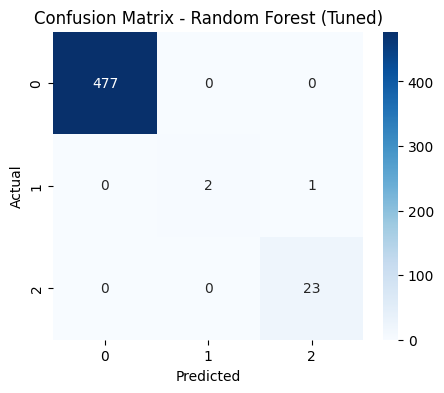


XGBoost (Tuned) Model Evaluation:
Accuracy Score: 0.996
F1 Score: 0.995
Precision: 0.996
Recall: 0.996


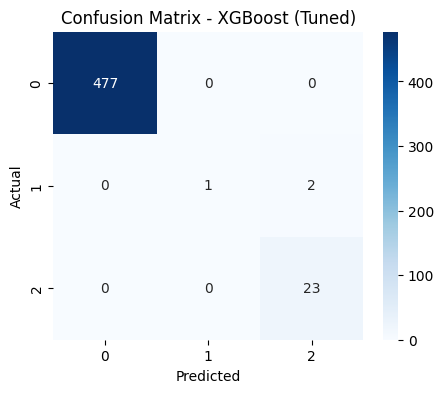

In [ ]:
# Gunakan model terbaik dari RandomizedSearchCV
best_rf = rf_random.best_estimator_
best_xgb = xgb_random.best_estimator_

# Fungsi Evaluasi Model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted')

    print(f"\n{model_name} Model Evaluation:")
    print(f"Accuracy Score: {accuracy:.3f}")
    print(f"F1 Score: {f1:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Evaluasi ulang setelah tuning
evaluate_model(best_rf, X_test, y_test, "Random Forest (Tuned)")
evaluate_model(best_xgb, X_test, y_test, "XGBoost (Tuned)")

## **e. Analisis Hasil Evaluasi Model Klasifikasi**

**1. Perbandingan Hasil Evaluasi Sebelum dan Setelah Tuning**
- Random Forest:

 - Tidak ada perubahan dalam metrik evaluasi setelah tuning. Accuracy, F1 Score, Precision, dan Recall tetap di angka 0.998.

 - Confusion matrix juga menunjukkan hasil prediksi yang sama sebelum dan sesudah tuning.

- XGBoost:

 - Setelah tuning, terjadi sedikit peningkatan dalam Accuracy (0.994 → 0.996), F1 Score (0.993 → 0.995), Precision (0.995 → 0.996), dan Recall (0.994 → 0.996).

 - Meskipun peningkatannya kecil, tuning tetap memberikan dampak positif pada performa model.

**2. Identifikasi Kelemahan Model**
- Precision atau Recall Rendah untuk Kelas Tertentu

 - Dari confusion matrix, terlihat bahwa kelas 1 (label tengah) memiliki kesalahan prediksi yang lebih tinggi dibandingkan kelas lain.

 - XGBoost memiliki sedikit lebih banyak kesalahan dalam mengklasifikasikan kelas 1 dibandingkan Random Forest.

- Overfitting atau Underfitting

 - Karena model memiliki accuracy sangat tinggi (~99.8%) dan metrik lain juga hampir sempurna, ada kemungkinan overfitting, terutama pada Random Forest.

 - Overfitting terjadi ketika model terlalu menyesuaikan diri dengan data pelatihan, sehingga performanya di dunia nyata mungkin tidak sebaik ini.

 - XGBoost mengalami sedikit perbaikan setelah tuning, yang menunjukkan tuning membantunya menggeneralisasi lebih baik.

**3. Rekomendasi Tindakan Lanjutan**
- Menyeimbangkan Data

 - Jika dataset memiliki distribusi kelas yang tidak seimbang, bisa mencoba teknik seperti SMOTE atau undersampling untuk meningkatkan kemampuan model dalam mengenali kelas minoritas.

- Coba Model Lain atau Ensembles

 - Meskipun Random Forest dan XGBoost sudah memberikan hasil yang sangat baik, kita bisa mencoba Stacking Model yang mengombinasikan beberapa model untuk mendapatkan hasil yang lebih stabil.

 - LightGBM atau CatBoost bisa menjadi alternatif lain yang layak dicoba.